# Rubin RSP Research Proposal: Testing the Intrinsic Response Sector (IRS) Framework

## 1) The Core Question: Causal Adjudication Under Matched Phenomenology

**Big picture:** This program asks whether the same uniform galaxy-scale phenomenology currently fit by Lambda CDM can be explained as an intrinsic spacetime response (IRS) rather than as an independent cold dark matter component.

**What this does and does not claim:** We do not assume first-order phenomenology must differ at the outset. IRS is being evaluated as an elegant candidate fit to the current CDM-consistent observational baseline, but with alternate causality. The central question is therefore causal interpretation under matched phenomenology, not curve-shape novelty by itself.

**Why this matters:** If two frameworks fit similar observables, adjudication shifts to cross-domain coherence: consistency across channels, parameter economy, cosmological compatibility, and external evidence (including direct-detection status).

## 2) Why Vera Rubin Observatory Is The Right Tool For This Test

This test requires three capabilities that no existing survey provides simultaneously:

### Scale: Samples Large Enough to Constrain Causal Claims

Rubin's very large samples allow meaningful discovery/validation splits, robust null tests, and tight uncertainty bounds. Small samples can mimic or hide weak effects and cannot reliably support causal adjudication.

### Homogeneity: One Pipeline, Fewer Systematic Ambiguities

Cross-survey stitching can manufacture or erase apparent trends. Rubin's uniform photometric pipeline reduces this ambiguity, so observed structure is less likely to be a calibration artifact.

### Breadth: Cross-Channel Tests in a Single Observational System

Rubin provides photometry, weak-lensing products, and time-domain variability within one coherent environment. This enables cross-channel consistency testing under shared coordinates, quality masks, and redshift conventions.

**Bottom line:** Without Rubin, causal adjudication remains statistically weak and systematics-limited. With Rubin, it becomes high-leverage and auditable.

## 3) Our Testing Strategy: Progressive Validation With Explicit Stopping Rules

Driven by the principle that negative results must be possible and publishable, we use staged gates:

- **Gate 0.5 (Transfer):** Can IRS proxy construction transfer from SPARC to Rubin without direction loss?
- **Gate 1 (Core trend):** Does the compactness-response relation reproduce on a large validation split?
- **Gate 2 (Robustness):** Does the trend survive shuffle and bootstrap adversarial checks?
- **Gate 3 (Lensing, contingent):** Is directionality consistent in a physically independent channel?
- **Gate 4 (Variability, contingent):** Is host-response enrichment consistent in time-domain behavior?

If any gate fails, the program stops. We do not retune thresholds to force passage.

## 4) Integrity: Why We Pre-Register and Lock Thresholds

Before loading live outcome data, we lock hypotheses and thresholds in preregistration artifacts and bind them with a cryptographic hash. If thresholds are changed after inspection, hash consistency fails and the change is auditable.

This prevents post-hoc threshold tuning and keeps the analysis falsification-grade.

## 5) Transparency and Reproducibility

The notebook writes machine-readable artifacts for each decision stage:

- Preregistration document (thresholds locked, hash-verified)
- Access gameplan (scope and governance)
- Gate outputs (effect sizes, pass/fail, provenance)
- Run summary (overall eligibility)

Artifacts explicitly declare provenance (`none`, `synthetic`, `live_tap`) and claim eligibility (`falsifier_grade`).

This is not a confirmation notebook. It is a decision notebook with formal stop conditions.

---

**Next sections:** See the following cells for detailed gate-by-gate mechanics, provenance-loop controls, and computational implementation.

## Gate Definitions and Move-Forward Criteria

Each gate is a decision point with explicit pass/fail criteria and stopping rules.

### Gate 0.5: SPARC-to-Rubin Transfer Validation

**Pass criteria:** N_overlap ≥ 20, |ρ(Rubin_IRS_proxy, SPARC_metric)| ≥ 0.40, sign matches expected direction

**Mechanism:** Identifies data-translation errors before population scaling.
- Why 20 samples: Spearman correlation SE on 20 pairs is ~0.23; with ρ = 0.40, the z-score is ~1.7, giving ~10% false-negative rate. Below N=20, errors become too frequent to distinguish signal from noise.
- Why 0.40 threshold: SPARC metrics already have measurement error. If transfer correlation is weaker, then Rubin IRS proxy construction is lossy relative to SPARC. Proceeding with weaker proxy magnifies noise downstream.
- Sign check: If direction flips, IRS physics or proxy definition is inverted in Rubin. Stop immediately; population tests will fail.
- **Failure action:** Stop. Do not proceed to Gate 1. Revise IRS proxy construction or coordinate system mapping.

### Gate 1: IRS Host-Photometry Trend Testing

**Pass criteria:** N ≥ 5000, |ρ_validation| ≥ 0.15, discovery and validation sign match

**Mechanism:** Tests reproducibility of trend on large, uniform sample with generalization guarantee.
- Why 5000: With 70/30 split, validation set is N=1500. Spearman correlation SE on 1500 pairs is ~0.026. With ρ=0.15, z-score is 5.8, giving <0.001% false-negative rate. Below N=5000, validation uncertainty becomes too large to reject weak signal.
- Why 0.15 threshold: Corresponds to ~2.25% of variance explained (ρ²). Weaker signal is below instrumental sensitivity for downstream physics applications.
- Sign match between discovery/validation: If signs differ, model is overfitting to discovery set. Trend is not reproducible. Stop.
- **Failure action:** Stop. Do not proceed to Gate 2. Revise proxy definitions or examine confounds.

### Gate 2: Adversarial Null + Bootstrap Robustness

**Pass criteria:** |E[ρ_shuffled]| ≤ 0.05, ρ CI95 excludes zero with p_empirical ≤ 0.05

**Mechanism:** Rejects null hypothesis (trend is random) with low false-positive rate.
- Label shuffling (200 iterations): Tests whether trend persists when labels are randomly permuted. If E[ρ_shuffled] > 0.05, the proxy definition or data processing introduces spurious correlation. Proceeding risks publishing artifact, not physics.
- Bootstrap CI: Resamples with replacement to estimate uncertainty. If CI includes zero, we cannot claim non-zero effect. If p_empirical > 0.05, null cannot be rejected at α=0.05 significance.
- **Failure action:** Stop. Trend is not robust. Examine whether proxies are circular (proxy defined from target variable) or whether latent confounds cause spurious correlation.

### Gate 3: Weak-Lensing Extension (Planned, Contingent on Gate 1/2 Live Pass)

**Pass criteria:** Tangential shear profiles show directional consistency with IRS/compactness bins across redshift slices

**Mechanism:** Validates IRS framework on gravity-based observable independent from photometry.
- Why lensing: Mass-density profiles (weak lensing) are determined by gravity, not luminosity. If IRS reflects host response to space-time curvature (IRS hypothesis), lensing profiles should match IRS predictions.
- Cross-channel coupling: If photometric Gate 1 passes but lensing Gate 3 fails, the trend is not physically meaningful; it is an artifact of photometric systematics or proxy definition.
- **Failure action:** Stop lensing program. Revise IRS interpretation; photometric trend is not causally linked to gravitational structure.

### Gate 4: AGN Variability + Host Enrichment (Planned, Contingent on Gate 1/2 Live Pass)

**Pass criteria:** Variable AGN rates in high-IRS hosts significantly exceed rates in low-IRS hosts under predefined enrichment threshold

**Mechanism:** Tests KSL (variability) as independent channel for IRS/KSL coupling.
- Why AGN variability: If IRS reflects host response to curvature, high-response hosts should have higher AGN accretion rates (KSL prediction). This is independent from photometric trends (different data stream).
- Enrichment test: Compute variability rates in IRS bins. Randomization test: shuffle IRS labels and recompute enrichment 1000×. If observed enrichment exceeds 95th percentile of null distribution, KSL coupling is detected.
- **Failure action:** Stop variability program. KSL coupling is not detected; either IRS/KSL are uncoupled, or coupling operates through different channels (not AGN).

### Why Gate Failures Are Stopping Conditions, Not Tuning Triggers

Once a gate fails, progression stops because:
1. **Model assumptions are falsified.** Moving to a later gate assumes earlier gates hold. Proceeding erodes scientific credibility.
2. **Posterior tuning is forbidden.** If Gate 1 fails, you cannot revise the Gate 1 threshold to make it pass and then run Gate 2. The preregistration lock hash will no longer match.
3. **Negative results have value.** Reporting "we tested X and it failed" is scientifically valuable. It rules out a wrong model early, saving research time elsewhere.
4. **Reproducibility requires honesty.** If you rerun the notebook after revising, the timestamp will show a new analysis. The original failure remains in the output record.


## Appendix A: How Integrity Controls Work (The Provenance Loop)

This section explains the exact mechanisms that prevent false claims from being made accidentally or by mistake.

### Data Flow: From Input to Claim Eligibility

```
cfg.dry_run = True/False    cfg.strict_falsifier_mode = True  cfg.allow_synthetic_data = False
           |                            |                              |
           +---────────────+────────────+──────────────────────────────+
                           |
                           v
        [Gate 0.5: Load overlap or fail]
                           |
                    data_mode = ?
                           |
            +──────────────+──────────────+
            |                             |
        dry_run?                     data_mode = live_tap?
            |                             |
         YES|                          YES|
            |                             |
            v                             v
        [Synthetic block]          [Live data path]
        data_mode = none                  |
            |                    gate05_data_mode = live_tap
            v                             |
        gate05_pass = False               v
        falsifier_grade = False    [Compute gate05 metrics]
                                          |
                                   gate05_pass = (rho_magnitude AND overlap_size AND sign_match)
                                   falsifier_grade = true
                                          |
                                          v
                            [Summary records both]
                            gate_results.gate05_pass = gate05_pass
                            falsifier_grade = (gate05 AND gate12 AND not dry_run)
```

### The Three-Point Integrity Check

**Point 1: Data provenance must be explicit.**
- Every data-loading cell (10, 13) records the source: `data_mode ∈ {none, synthetic, live_tap}`.
- If dry_run and strict_mode, only `none` is allowed; synthetic is blocked.
- If live_tap, the live TAP query log is implicitly retained in Cell 20 summary.

**Point 2: Gate pass logic is conjunctive, not disjunctive.**
- English: `gate_pass = (live_provenance) AND (thresholds_met)`.
- Code: `gate_pass = gate_pass if is_falsifier_grade else False`.
- Never: `gate_pass = thresholds_met OR has_artifact`.
- Result: Stale or synthetic results cannot satisfy a gate pass no matter how large the effect size.

**Point 3: Readiness check recomputes the lock hash.**
- Cell 21 reads the preregistration and gameplan artifacts.
- It recomputes the lock hash using the current thresholds.
- If the recomputed hash does not match the recorded hash, an integrity warning is raised.
- Rationale: If someone edits thresholds between Cell 4 and Cell 21, the mismatch is caught.

### Why This Prevents Misinterpretation

**Scenario 1**: Researcher accidentally runs in dry_run mode, sees large effect size, tries to cite it.
- Result: `falsifier_grade = false` flag is in the artifact. Any serious reviewer checks this field. Claim is caught as invalid.

**Scenario 2**: Researcher tunes a threshold after seeing results to make Gate 1 pass.
- Result: They edit the threshold in Cell 3. They re-run. The preregistration lock hash in Cell 4 recomputes. But Cell 21 's recomputation no longer matches. Integrity warning. Submitted artifacts will show hash mismatch. Fraud is detected.

**Scenario 3**: Researcher loads stale Gate 1 metrics from a previous run, re-runs summary without re-running Gate 1.
- Result: Cell 15 is not re-executed, so `gate1_data_mode` remains set to its prior (synthetic) value. Cell 20 computes `gate12_falsifier = (gate1_data_mode == 'live_tap')`, which is false. Summary reports `gate1_pass = false` and `falsifier_grade = false`. Stale data is not mistaken for fresh data.

### Audit Trail for Reviewers

A Rubin reviewer can verify integrity in three steps:

1. Read `run_summary.json`: Check that `falsifier_grade = true`, `dry_run = false`, and all required gate passes are `true`.
2. Read `preregistered_plan.json` and `access_request_gameplan.json`: Verify lock hash. Look for post-hoc threshold changes.
3. Check artifact dates: Run `ls -lht rubin_rsp/out/` and ensure all gate artifacts are newer than the last notebook execution.

If all three checks pass, the reviewer can be confident the claims are valid.

In [39]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

@dataclass
class Config:
    dry_run: bool = True  # Keep True only for plumbing checks; falsifier-grade claims require False
    seed: int = 42
    out_dir: str = "rubin_rsp/out"

    # Strict mode: prevents placeholder/synthetic data from being used for pass claims.
    strict_falsifier_mode: bool = True
    allow_synthetic_data: bool = False

    # Replace with actual RSP TAP endpoint when approved
    tap_endpoint: str = "https://data.lsst.cloud/api/tap"

    # Replace with actual DR table names from the RSP schema browser
    phot_table: str = "dr1.object"
    lens_table: str = "dr1.shape_measurements"
    agn_table: str = "dr1.source"

    # First low-hanging-fruit sample controls
    z_min: float = 0.02
    z_max: float = 0.30
    min_n: int = 5000

    # Preregistered minimum effect thresholds for move-forward
    min_abs_rho: float = 0.15
    max_null_rho: float = 0.05

def _detect_repo_root() -> Path:
    roots = [Path.cwd(), *Path.cwd().parents]
    for root in roots:
        if (root / "rubin_rsp").exists() and (root / "toy_models").exists():
            return root
    return Path.cwd()

REPO_ROOT_CANON = _detect_repo_root()
DATA_DIR = REPO_ROOT_CANON / "rubin_rsp" / "data"

cfg = Config()
cfg.out_dir = str(REPO_ROOT_CANON / "rubin_rsp" / "out")
rng = np.random.default_rng(cfg.seed)

out_dir = Path(cfg.out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

print("Config ready")
print(json.dumps(asdict(cfg), indent=2))

Config ready
{
  "dry_run": true,
  "seed": 42,
  "out_dir": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\out",
  "strict_falsifier_mode": true,
  "allow_synthetic_data": false,
  "tap_endpoint": "https://data.lsst.cloud/api/tap",
  "phot_table": "dr1.object",
  "lens_table": "dr1.shape_measurements",
  "agn_table": "dr1.source",
  "z_min": 0.02,
  "z_max": 0.3,
  "min_n": 5000,
  "min_abs_rho": 0.15,
  "max_null_rho": 0.05
}


In [50]:
import hashlib

preregistered = {
    "study_name": "IRS_firstpass_rubin_host_photometry",
    "author_orcid": "0009-0004-8679-9155",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "hypotheses": [
        {
            "id": "H1",
            "statement": "IRS proxy increases with host compactness proxy.",
            "metric": "spearman_rho(irs_proxy, compactness_proxy)",
            "pass_if": f"abs(rho) >= {cfg.min_abs_rho}"
        },
        {
            "id": "H2",
            "statement": "IRS proxy trend is non-random under label shuffles.",
            "metric": "abs(mean_shuffle_rho)",
            "pass_if": f"abs(mean_shuffle_rho) <= {cfg.max_null_rho}"
        }
    ],
    "stop_conditions": [
        "Fail H1 on validation split",
        "Fail null test robustness (H2)",
        "N below minimum for stable inference"
    ]
}

prereg_path = out_dir / "preregistered_plan.json"
prereg_path.write_text(json.dumps(preregistered, indent=2), encoding="utf-8")

# Lock key scientific assumptions with a deterministic hash to support auditability in access requests.
lock_payload = {
    "study_name": preregistered["study_name"],
    "hypotheses": preregistered["hypotheses"],
    "stop_conditions": preregistered["stop_conditions"],
    "thresholds": {
        "min_abs_rho": cfg.min_abs_rho,
        "max_null_rho": cfg.max_null_rho,
        "min_n": cfg.min_n,
        "transfer_min_overlap": TRANSFER_MIN_OVERLAP if "TRANSFER_MIN_OVERLAP" in globals() else 20,
        "transfer_min_abs_rho": TRANSFER_MIN_ABS_RHO if "TRANSFER_MIN_ABS_RHO" in globals() else 0.40,
    },
}
lock_text = json.dumps(lock_payload, sort_keys=True, separators=(",", ":"))
preregistration_lock = {
    "algorithm": "sha256",
    "hash": hashlib.sha256(lock_text.encode("utf-8")).hexdigest(),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

gameplan = {
    "program_name": "Rubin IRS/KSL Falsification Program",
    "access_purpose": "Run pre-registered, falsification-first tests on Rubin data with strict provenance controls.",
    "scientific_case": {
        "primary_objective": "Test reproducible IRS-host structure correlations under out-of-sample validation and null robustness.",
        "secondary_objective": "Attempt transfer-validation from SPARC priors before scaling to Rubin-native population tests.",
        "falsifier_commitment": [
            "Any failed gate is a formal stop condition, not a tuning trigger.",
            "Null and negative outcomes are reportable outcomes.",
            "No synthetic-mode result is presented as empirical support."
        ]
    },
    "staged_execution": [
        {
            "phase": "Gate 0.5",
            "goal": "SPARC-Rubin overlap transfer test",
            "minimum_success": "N_overlap >= 20 and |rho| >= 0.40 with expected sign",
            "rationale": "Validates that IRS proxy can be computed consistently in Rubin on known targets. Catches data-translation errors early before scaling to full population."
        },
        {
            "phase": "Gate 1",
            "goal": "Host photometry trend validation",
            "minimum_success": f"N >= {cfg.min_n} and |rho_validation| >= {cfg.min_abs_rho}",
            "rationale": "Tests core hypothesis on large, uniform sample with discovery/validation split. Out-of-sample validation prevents overfitting; inconsistent signs between splits indicate noise."
        },
        {
            "phase": "Gate 2",
            "goal": "Adversarial null and bootstrap robustness",
            "minimum_success": f"|mean_shuffle_rho| <= {cfg.max_null_rho}",
            "rationale": "Label shuffles test whether trend is robust to randomization. Large null correlations indicate latent confounds or systematic structure in proxy definition. Bootstrap CI ensures uncertainty is acceptable for claims."
        },
        {
            "phase": "Gate 3",
            "goal": "Weak-lensing extension",
            "minimum_success": "Directional consistency across bins after quality controls",
            "rationale": "Weak lensing is gravity-based measurement independent from photometry. Tests whether IRS framework predictions remain valid on physically independent observable. Failure here indicates photometric trends are unrelated to gravitational mass."
        },
        {
            "phase": "Gate 4",
            "goal": "AGN variability channel",
            "minimum_success": "Non-random variability-host coupling under predefined thresholds",
            "rationale": "Second independent channel strengthens physical coupling case. Tests whether variable AGN show non-random enrichment in IRS-predicted high-response hosts. Directional inconsistency with Gate 1 indicates IRS framework is incomplete."
        }
    ],
    "data_access_scope": {
        "principle": "minimum necessary data for hypothesis testing",
        "core_tables": [cfg.phot_table, cfg.lens_table, cfg.agn_table],
        "query_constraints": [
            "Explicit row limits in exploratory queries (LIMIT clauses in all ADQL)",
            "Column-minimized projections (tuples include only required fields, not all-columns wildcard)",
            "Coordinate-based overlap only for preregistered transfer gate (no cross-match of external catalogs)"
        ],
        "export_policy": "Derived metrics and aggregated diagnostics are preferred over broad raw exports.",
        "rationale": "Focused query design ensures we request only what is necessary for the hypothesis tests. Avoids bulk data exports and reduces load on RSP. Preregistration locks which overlap operations are allowed, preventing exploratory data dredging."
    },
    "integrity_controls": {
        "strict_falsifier_mode": bool(getattr(cfg, "strict_falsifier_mode", True)),
        "allow_synthetic_data": bool(getattr(cfg, "allow_synthetic_data", False)),
        "dry_run": bool(cfg.dry_run),
        "requirements_for_claims": [
            "cfg.dry_run must be False",
            "Gate 0.5 provenance must be live_tap",
            "Gate 1/2 provenance must be live_tap",
            "run_summary.json must report falsifier_grade=true"
        ],
        "rationale_for_conjunction": "All four conditions must be true simultaneously (boolean AND). If any condition is false, claim eligibility is false. This prevents accidental claims from stale data, synthetic plumbing runs, or incomplete live runs.",
        "preregistration_lock": preregistration_lock,
    },
    "deliverables_for_rubin_review": [
        {
            "artifact": "preregistered_plan.json",
            "purpose": "Verify no post-hoc threshold tuning; lock hash proof of pre-analysis registration"
        },
        {
            "artifact": "gate05_transfer_metrics.json",
            "purpose": "Verify SPARC-Rubin transfer is sound before scaling to full Rubin population"
        },
        {
            "artifact": "gate1_metrics.json",
            "purpose": "Check whether core hypothesis is supported in discovery/validation split"
        },
        {
            "artifact": "gate2_robustness.json",
            "purpose": "Verify robustness under label shuffles and bootstrap resampling"
        },
        {
            "artifact": "run_summary.json",
            "purpose": "Determine claim eligibility and falsifier-grade status at a glance"
        },
        {
            "artifact": "VERA_RUBIN_OPERATORS_MANUAL.md",
            "purpose": "Step-by-step operational guide for running notebook cells and interpreting outputs"
        },
        {
            "artifact": "RUBIN_SCIENCE_CASE_AND_AUDIT.md",
            "purpose": "Robust audit of notebook implementation, residual risks, and mitigation"
        }
    ],
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

gameplan_path = out_dir / "access_request_gameplan.json"
gameplan_path.write_text(json.dumps(gameplan, indent=2), encoding="utf-8")

print(f"Saved preregistration scaffold: {prereg_path}")
print(f"Saved access request gameplan: {gameplan_path}")
print(f"Preregistration lock hash: {preregistration_lock['hash']}")

Saved preregistration scaffold: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\preregistered_plan.json
Saved access request gameplan: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\access_request_gameplan.json
Preregistration lock hash: c9a7b7c4df91bdae2a708ccf5bd16d5e288f23bd4e328259e8aa34e5ff7c322b


## Gate 0.5 (SPARC-175 -> Rubin Transfer Validation)

This is the first empirical bridge test and should run before full Rubin-native scaling.

Goal:
- Re-test the same SPARC galaxy population inside Rubin coverage where possible.
- Compare Rubin-derived IRS proxy behavior against SPARC-derived outputs (`Q_est`, `Q_best`, or equivalent ranking metric).

Why this gate is elegant:
- Uses known targets and known prior outputs.
- Validates your RSP workflow with immediate interpretability.
- Distinguishes data-translation mismatch from model mismatch early.

Pass criteria (initial defaults):
- `N_overlap >= 20` matched galaxies.
- `|spearman_rho(Rubin_proxy, SPARC_metric)| >= 0.40` on overlap sample.
- Direction/sign is consistent with preregistered expectation.
- Shuffle-null mean correlation remains near zero.

Fail conditions:
- Overlap too small for stable inference.
- Correlation magnitude below threshold in validation split.
- Sign instability under bootstrap/null checks.

Note:
- This is a transfer-validation gate, not a literal full kinematic reproduction of SPARC rotmod curves from Rubin imaging alone.

In [40]:
# Gate 0.5 configuration and reference-data loader

from pathlib import Path

TRANSFER_MIN_OVERLAP = 20
TRANSFER_MIN_ABS_RHO = 0.40

# Expected sign: +1 for positive trend, -1 for negative trend.
TRANSFER_EXPECTED_SIGN = +1


def _find_existing_path(candidates: list[str]) -> Path | None:
    roots = [Path.cwd(), *Path.cwd().parents]
    for rel in candidates:
        for root in roots:
            p = root / rel
            if p.exists():
                return p
    return None


SPARC_REFERENCE_CANDIDATES = [
    "rubin_rsp/data/sparc175_reference_independent.csv",
    "data/sparc175_reference_independent.csv",
    "rubin_rsp/data/sparc175_reference.csv",
    "data/sparc175_reference.csv",
    "toy_models/out_sparc_runs_full_with_composition/q_est.csv",
    "toy_models/out_sparc_runs_full_with_composition/summary.csv",
]


def load_sparc_reference(candidates: list[str]) -> pd.DataFrame:
    p = _find_existing_path(candidates)
    if p is not None:
        df = pd.read_csv(p)
        print(f"Loaded SPARC reference: {p} (rows={len(df):,})")
        return df

    # Create an empty template if no source exists yet.
    template = Path("rubin_rsp/data/sparc175_reference_template.csv")
    template.parent.mkdir(parents=True, exist_ok=True)
    if not template.exists():
        pd.DataFrame(
            {
                "galaxy": [],
                "ra_deg": [],
                "dec_deg": [],
                "sparc_metric": [],
            }
        ).to_csv(template, index=False)
    print("No SPARC reference table found. Created template:", template)
    return pd.DataFrame(columns=["galaxy", "ra_deg", "dec_deg", "sparc_metric"])


sparc_ref = load_sparc_reference(SPARC_REFERENCE_CANDIDATES)
sparc_ref.head()

Loaded SPARC reference: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\data\sparc175_reference_independent.csv (rows=175)


,galaxy,ra_deg,dec_deg,sparc_metric,coord_source,catalog_name
0,CamB,73.27958,67.09917,42.988163,VizieR:J/AJ/152/157/table1,CamB
1,D512-2,218.33465,26.99804,913.235409,VizieR:J/AJ/152/157/table1,D512-2
2,D564-8,135.72232,20.07561,386.793571,VizieR:J/AJ/152/157/table1,D564-8
3,D631-7,119.25428,14.39657,2874.305043,VizieR:J/AJ/152/157/table1,D631-7
4,DDO064,147.59487,31.48828,1565.312462,VizieR:J/AJ/152/157/table1,DDO064


In [25]:
# Build SPARC reference table (galaxy, ra_deg, dec_deg, sparc_metric)
# Merge q_est.csv with coordinates resolved by name using overrides + cache + VizieR + SIMBAD/NED.

from datetime import datetime, timezone
from pathlib import Path
import json
import re
import time

import numpy as np
import pandas as pd

if "out_dir" not in globals():
    out_dir = Path("rubin_rsp/out")
    out_dir.mkdir(parents=True, exist_ok=True)


def _find_existing(rel_candidates: list[str]) -> Path | None:
    roots = [Path.cwd(), *Path.cwd().parents]
    for rel in rel_candidates:
        for root in roots:
            p = root / rel
            if p.exists():
                return p
    return None


def _normalize_name(name: str) -> str:
    return re.sub(r"\s+", "", str(name)).upper().strip()


def _possible_keys(name: str) -> set[str]:
    raw = str(name).strip().upper()
    base = _normalize_name(raw)
    keys = {base}

    for pfx in ["NGC", "UGC", "IC", "PGC", "DDO"]:
        m = re.match(rf"^{pfx}0*(\d+)$", base)
        if m:
            keys.add(f"{pfx}{int(m.group(1))}")

    # Variants like ESO079-G014 / ESO 079-G014
    keys.add(base.replace("-", ""))
    return keys


def _name_variants(name: str) -> list[str]:
    raw = str(name).strip()
    variants = [raw, raw.replace("_", " ")]

    patterns = [
        r"^(NGC)(\d+)$",
        r"^(UGC)(\d+)$",
        r"^(IC)(\d+)$",
        r"^(DDO)(\d+)$",
        r"^(ESO)(\d+[-A-Z]*\d*)$",
        r"^(PGC)(\d+)$",
        r"^(KK)(\d+[-]\d+)$",
    ]

    for p in patterns:
        m = re.match(p, raw, flags=re.IGNORECASE)
        if m:
            variants.append(f"{m.group(1).upper()} {m.group(2)}")

    dedup = []
    seen = set()
    for v in variants:
        key = _normalize_name(v)
        if v and key not in seen:
            dedup.append(v)
            seen.add(key)
    return dedup


Q_EST_PATH = _find_existing([
    "toy_models/out_sparc_runs_full_with_composition/q_est.csv",
])
if Q_EST_PATH is None:
    raise FileNotFoundError("Could not locate toy_models/out_sparc_runs_full_with_composition/q_est.csv")

# q_est.csv lives under <repo>/toy_models/...; this recovers <repo> robustly.
REPO_ROOT = Q_EST_PATH.parent.parent.parent

SPARC_REF_OUT = REPO_ROOT / "rubin_rsp/data/sparc175_reference.csv"
COORD_CACHE_PATH = REPO_ROOT / "rubin_rsp/data/sparc_coord_cache.csv"
COORD_OVERRIDE_PATH = REPO_ROOT / "rubin_rsp/data/sparc175_coord_overrides.csv"
BUILD_REPORT_PATH = out_dir / "gate05_sparc_reference_build_report.json"


def _load_cache(path: Path) -> pd.DataFrame:
    if path.exists():
        df = pd.read_csv(path)
    else:
        df = pd.DataFrame(columns=["galaxy", "ra_deg", "dec_deg", "source", "resolved_at"])

    keep = ["galaxy", "ra_deg", "dec_deg", "source", "resolved_at"]
    for c in keep:
        if c not in df.columns:
            df[c] = np.nan
    df = df[keep].copy()
    df["galaxy_key"] = df["galaxy"].astype(str).map(_normalize_name)
    return df


def _load_overrides(path: Path) -> pd.DataFrame:
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(columns=["galaxy", "ra_deg", "dec_deg", "note"]).to_csv(path, index=False)

    df = pd.read_csv(path)
    if not {"galaxy", "ra_deg", "dec_deg"}.issubset(df.columns):
        raise ValueError("Override file must contain columns: galaxy, ra_deg, dec_deg")

    df = df.copy()
    df["galaxy_key"] = df["galaxy"].astype(str).map(_normalize_name)
    return df


def _parse_deg(v, is_ra: bool) -> float | None:
    if pd.isna(v):
        return None
    try:
        return float(v)
    except Exception:
        pass

    try:
        from astropy import units as u
        from astropy.coordinates import Angle
        if is_ra:
            return float(Angle(str(v), unit=u.hourangle).degree)
        return float(Angle(str(v), unit=u.deg).degree)
    except Exception:
        return None


def _load_vizier_coords() -> pd.DataFrame:
    # Bulk resolver: much faster and more reliable than one-object-at-a-time remote queries.
    try:
        from astroquery.vizier import Vizier

        Vizier.ROW_LIMIT = -1
        vz = Vizier(columns=["*"])
        tables = vz.get_catalogs("J/AJ/152/157")
    except Exception:
        return pd.DataFrame(columns=["galaxy", "ra_deg", "dec_deg", "source"])

    records = []
    for t in tables:
        cols = list(getattr(t, "colnames", []))
        if not cols:
            continue

        name_col = None
        for c in ["Galaxy", "Name", "ID", "SPARC", "Obj", "Object"]:
            if c in cols:
                name_col = c
                break
        if name_col is None:
            continue

        ra_col = None
        dec_col = None
        for c in ["RAJ2000", "RA_ICRS", "RAdeg", "RA"]:
            if c in cols:
                ra_col = c
                break
        for c in ["DEJ2000", "DE_ICRS", "DEdeg", "DEC", "Dec"]:
            if c in cols:
                dec_col = c
                break

        if ra_col is None or dec_col is None:
            continue

        pdf = t.to_pandas()
        for _, r in pdf.iterrows():
            g = str(r.get(name_col, "")).strip()
            if not g:
                continue
            ra = _parse_deg(r.get(ra_col), is_ra=True)
            dec = _parse_deg(r.get(dec_col), is_ra=False)
            if ra is None or dec is None:
                continue
            records.append(
                {
                    "galaxy": g,
                    "ra_deg": ra,
                    "dec_deg": dec,
                    "source": "VizieR:J/AJ/152/157",
                }
            )

    if not records:
        return pd.DataFrame(columns=["galaxy", "ra_deg", "dec_deg", "source"])

    vdf = pd.DataFrame(records)
    vdf["galaxy_key"] = vdf["galaxy"].astype(str).map(_normalize_name)
    return vdf.drop_duplicates(subset=["galaxy_key"], keep="first")


def _build_online_resolvers(timeout_s: int):
    simbad = None
    ned = None

    try:
        from astroquery.simbad import Simbad
        simbad = Simbad()
        simbad.TIMEOUT = timeout_s
        simbad.add_votable_fields("ra(d)", "dec(d)")
    except Exception:
        simbad = None

    try:
        from astroquery.ipac.ned import Ned
        Ned.TIMEOUT = timeout_s
        ned = Ned
    except Exception:
        ned = None

    return simbad, ned


def _resolve_one_online(galaxy: str, simbad, ned) -> dict | None:
    for candidate in _name_variants(galaxy):
        if simbad is not None:
            try:
                t = simbad.query_object(candidate)
                if t is not None and len(t) > 0:
                    return {
                        "galaxy": galaxy,
                        "ra_deg": float(t["RA_d"][0]),
                        "dec_deg": float(t["DEC_d"][0]),
                        "source": f"SIMBAD:{candidate}",
                        "resolved_at": datetime.now(timezone.utc).isoformat(),
                    }
            except Exception:
                pass

        if ned is not None:
            try:
                t = ned.query_object(candidate)
                if t is not None and len(t) > 0 and {"RA", "DEC"}.issubset(set(t.colnames)):
                    return {
                        "galaxy": galaxy,
                        "ra_deg": float(t["RA"][0]),
                        "dec_deg": float(t["DEC"][0]),
                        "source": f"NED:{candidate}",
                        "resolved_at": datetime.now(timezone.utc).isoformat(),
                    }
            except Exception:
                pass

    return None


def build_sparc175_reference(
    q_est_path: Path = Q_EST_PATH,
    out_path: Path = SPARC_REF_OUT,
    cache_path: Path = COORD_CACHE_PATH,
    override_path: Path = COORD_OVERRIDE_PATH,
    resolve_online: bool = True,
    online_timeout_s: int = 3,
    max_online_new: int = 20,
) -> tuple[pd.DataFrame, dict]:
    q = pd.read_csv(q_est_path)
    if not {"galaxy", "q_est_kms2"}.issubset(q.columns):
        raise ValueError("q_est.csv must contain columns: galaxy, q_est_kms2")

    base = q[["galaxy", "q_est_kms2"]].copy().rename(columns={"q_est_kms2": "sparc_metric"})
    base["galaxy_key"] = base["galaxy"].astype(str).map(_normalize_name)

    cache = _load_cache(cache_path)
    overrides = _load_overrides(override_path)

    cache_map = {row["galaxy_key"]: row for _, row in cache.iterrows()}
    override_map = {row["galaxy_key"]: row for _, row in overrides.iterrows()}

    vizier_df = _load_vizier_coords() if resolve_online else pd.DataFrame(columns=["galaxy_key"])
    vizier_map = {}
    if not vizier_df.empty:
        for _, r in vizier_df.iterrows():
            for k in _possible_keys(r["galaxy"]):
                if k not in vizier_map:
                    vizier_map[k] = r

    simbad, ned = _build_online_resolvers(timeout_s=online_timeout_s) if resolve_online else (None, None)
    can_resolve_online = resolve_online and (simbad is not None or ned is not None)

    coord_rows = []
    unresolved = []
    n_override = 0
    n_cache = 0
    n_vizier = 0
    n_online = 0
    n_missing = 0

    for i, (_, row) in enumerate(base.iterrows(), start=1):
        g = row["galaxy"]
        gk = row["galaxy_key"]

        if gk in override_map:
            r = override_map[gk]
            coord_rows.append(
                {
                    "galaxy": g,
                    "ra_deg": float(r["ra_deg"]),
                    "dec_deg": float(r["dec_deg"]),
                    "coord_source": "override",
                }
            )
            n_override += 1
            continue

        if gk in cache_map and pd.notna(cache_map[gk].get("ra_deg")) and pd.notna(cache_map[gk].get("dec_deg")):
            r = cache_map[gk]
            coord_rows.append(
                {
                    "galaxy": g,
                    "ra_deg": float(r["ra_deg"]),
                    "dec_deg": float(r["dec_deg"]),
                    "coord_source": str(r.get("source", "cache")),
                }
            )
            n_cache += 1
            continue

        vmatch = None
        for k in _possible_keys(g):
            if k in vizier_map:
                vmatch = vizier_map[k]
                break
        if vmatch is not None:
            coord_rows.append(
                {
                    "galaxy": g,
                    "ra_deg": float(vmatch["ra_deg"]),
                    "dec_deg": float(vmatch["dec_deg"]),
                    "coord_source": str(vmatch.get("source", "vizier")),
                }
            )
            cache = pd.concat(
                [
                    cache,
                    pd.DataFrame(
                        [
                            {
                                "galaxy": g,
                                "ra_deg": float(vmatch["ra_deg"]),
                                "dec_deg": float(vmatch["dec_deg"]),
                                "source": str(vmatch.get("source", "vizier")),
                                "resolved_at": datetime.now(timezone.utc).isoformat(),
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )
            n_vizier += 1
            continue

        resolved = None
        if can_resolve_online and n_online < max_online_new:
            resolved = _resolve_one_online(g, simbad=simbad, ned=ned)
            time.sleep(0.05)

        if resolved is not None:
            coord_rows.append(
                {
                    "galaxy": g,
                    "ra_deg": float(resolved["ra_deg"]),
                    "dec_deg": float(resolved["dec_deg"]),
                    "coord_source": resolved["source"],
                }
            )
            cache = pd.concat([cache, pd.DataFrame([resolved])], ignore_index=True)
            n_online += 1
        else:
            coord_rows.append(
                {
                    "galaxy": g,
                    "ra_deg": np.nan,
                    "dec_deg": np.nan,
                    "coord_source": "missing",
                }
            )
            unresolved.append(g)
            n_missing += 1

        if i % 25 == 0:
            print(f"processed {i}/{len(base)} galaxies")

    coord_df = pd.DataFrame(coord_rows)
    ref = base[["galaxy", "sparc_metric"]].merge(coord_df, on="galaxy", how="left")
    ref = ref[["galaxy", "ra_deg", "dec_deg", "sparc_metric", "coord_source"]]

    out_path.parent.mkdir(parents=True, exist_ok=True)
    ref.to_csv(out_path, index=False)

    cache["galaxy_key"] = cache["galaxy"].astype(str).map(_normalize_name)
    cache = cache.sort_values("resolved_at").drop_duplicates(subset=["galaxy_key"], keep="last")
    cache = cache[["galaxy", "ra_deg", "dec_deg", "source", "resolved_at"]]
    cache.to_csv(cache_path, index=False)

    report = {
        "q_est_path": str(q_est_path),
        "out_path": str(out_path),
        "cache_path": str(cache_path),
        "override_path": str(override_path),
        "resolve_online": bool(resolve_online),
        "online_timeout_s": int(online_timeout_s),
        "max_online_new": int(max_online_new),
        "n_total": int(len(ref)),
        "n_override": int(n_override),
        "n_cache": int(n_cache),
        "n_vizier": int(n_vizier),
        "n_online": int(n_online),
        "n_missing": int(n_missing),
        "unresolved_examples": unresolved[:20],
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }
    return ref, report


# Function definitions only in this cell.
# Use the next cells to run safe-mode or bounded online enrichment.

In [26]:
# Safe non-blocking preemptive run (offline-first)
# If an independently validated table exists, use it directly as canonical input.

INDEPENDENT_REF_PATH = _find_existing_path([
    "rubin_rsp/data/sparc175_reference_independent.csv",
    "data/sparc175_reference_independent.csv",
])

if INDEPENDENT_REF_PATH is not None:
    sparc_ref = pd.read_csv(INDEPENDENT_REF_PATH)
    sparc_ref_build_report = {
        "mode": "independent_prebuilt",
        "n_total": int(len(sparc_ref)),
        "n_missing": int(sparc_ref[["ra_deg", "dec_deg"]].isna().any(axis=1).sum()) if {"ra_deg", "dec_deg"}.issubset(sparc_ref.columns) else None,
        "source_path": str(INDEPENDENT_REF_PATH),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }
else:
    sparc_ref, sparc_ref_build_report = build_sparc175_reference(
        resolve_online=False,
        online_timeout_s=2,
        max_online_new=0,
    )

BUILD_REPORT_PATH.write_text(json.dumps(sparc_ref_build_report, indent=2), encoding="utf-8")

print("SPARC reference build report (safe mode):")
print(json.dumps(sparc_ref_build_report, indent=2))
print(f"Saved report: {BUILD_REPORT_PATH}")
if "SPARC_REF_OUT" in globals():
    print(f"Saved reference: {SPARC_REF_OUT}")
print(f"Override file: {COORD_OVERRIDE_PATH}")
print(f"Cache file: {COORD_CACHE_PATH}")

sparc_ref.head()

SPARC reference build report (safe mode):
{
  "mode": "independent_prebuilt",
  "n_total": 175,
  "n_missing": 0,
  "source_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\data\\sparc175_reference_independent.csv",
  "timestamp_utc": "2026-03-23T16:22:33.771297+00:00"
}
Saved report: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate05_sparc_reference_build_report.json
Saved reference: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\data\sparc175_reference.csv
Override file: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\data\sparc175_coord_overrides.csv
Cache file: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\data\sparc_coord_cache.csv


,galaxy,ra_deg,dec_deg,sparc_metric,coord_source,catalog_name
0,CamB,73.27958,67.09917,42.988163,VizieR:J/AJ/152/157/table1,CamB
1,D512-2,218.33465,26.99804,913.235409,VizieR:J/AJ/152/157/table1,D512-2
2,D564-8,135.72232,20.07561,386.793571,VizieR:J/AJ/152/157/table1,D564-8
3,D631-7,119.25428,14.39657,2874.305043,VizieR:J/AJ/152/157/table1,D631-7
4,DDO064,147.59487,31.48828,1565.312462,VizieR:J/AJ/152/157/table1,DDO064


In [ ]:
# Bounded online enrichment pass (VizieR bulk + limited SIMBAD/NED fallback)
# Skip this when the independent canonical table already has full coordinates.

INDEPENDENT_REF_PATH = _find_existing_path([
    "rubin_rsp/data/sparc175_reference_independent.csv",
    "data/sparc175_reference_independent.csv",
])

if INDEPENDENT_REF_PATH is not None:
    sparc_ref = pd.read_csv(INDEPENDENT_REF_PATH)
    missing_now = int(sparc_ref[["ra_deg", "dec_deg"]].isna().any(axis=1).sum()) if {"ra_deg", "dec_deg"}.issubset(sparc_ref.columns) else None
    sparc_ref_build_report = {
        "mode": "independent_prebuilt_skip_enrichment",
        "n_total": int(len(sparc_ref)),
        "n_missing": missing_now,
        "source_path": str(INDEPENDENT_REF_PATH),
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }
else:
    sparc_ref, sparc_ref_build_report = build_sparc175_reference(
        resolve_online=True,
        online_timeout_s=4,
        max_online_new=40,
    )

BUILD_REPORT_PATH.write_text(json.dumps(sparc_ref_build_report, indent=2), encoding="utf-8")

coverage = 1.0 - (sparc_ref["ra_deg"].isna().mean()) if "ra_deg" in sparc_ref.columns else float("nan")
print("SPARC reference build report (bounded online):")
print(json.dumps(sparc_ref_build_report, indent=2))
print(f"Coordinate coverage: {coverage:.1%}")
print(f"Saved report: {BUILD_REPORT_PATH}")
if "SPARC_REF_OUT" in globals():
    print(f"Saved reference: {SPARC_REF_OUT}")
print(f"Override file: {COORD_OVERRIDE_PATH}")
print(f"Cache file: {COORD_CACHE_PATH}")

sparc_ref.head()

C:\Users\goarm\AppData\Local\Temp\ipykernel_483716\2422722076.py:211: DeprecationWarning: 'ra(d)' has been renamed 'ra'. You'll see it appearing with its new name in the output table
  simbad.add_votable_fields("ra(d)", "dec(d)")
C:\Users\goarm\AppData\Local\Temp\ipykernel_483716\2422722076.py:211: DeprecationWarning: 'dec(d)' has been renamed 'dec'. You'll see it appearing with its new name in the output table
  simbad.add_votable_fields("ra(d)", "dec(d)")


processed 25/175 galaxies
processed 50/175 galaxies
processed 75/175 galaxies
processed 100/175 galaxies
processed 125/175 galaxies
processed 150/175 galaxies
processed 175/175 galaxies
SPARC reference build report (bounded online):
{
  "q_est_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\toy_models\\out_sparc_runs_full_with_composition\\q_est.csv",
  "out_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\data\\sparc175_reference.csv",
  "cache_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\data\\sparc_coord_cache.csv",
  "override_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\data\\sparc175_coord_overrides.csv",
  "resolve_online": true,
  "online_timeout_s": 4,
  "max_online_new": 40,
  "n_total": 175,
  "n_override": 0,
  "n_cache": 0,
  "n_vizier": 0,
  "n_online": 0,
  "n_missing": 175,
  "unresolved_examples": [
    "CamB",
    "D512-2",
    "D564-8",
    "D631-7",
    "DDO064",
  

,galaxy,ra_deg,dec_deg,sparc_metric,coord_source
0,CamB,NaN,NaN,42.988163,missing
1,D512-2,NaN,NaN,913.235409,missing
2,D564-8,NaN,NaN,386.793571,missing
3,D631-7,NaN,NaN,2874.305043,missing
4,DDO064,NaN,NaN,1565.312462,missing


In [41]:
# Gate 0.5 live automation: schema discovery + SPARC-Rubin overlap generation

from typing import Iterable


def _first_existing(columns: set[str], candidates: Iterable[str]) -> str | None:
    for c in candidates:
        if c in columns:
            return c
    return None


def _discover_table_columns(service, table_name: str) -> set[str]:
    q = f"""
SELECT column_name
FROM TAP_SCHEMA.columns
WHERE table_name = '{table_name}'
""".strip()
    out = service.search(q).to_table().to_pandas()
    return set(out["column_name"].astype(str).tolist())


def _resolve_overlap_colmap(rubin_columns: set[str]) -> dict[str, str | None]:
    aliases = {
        "objectId": ["objectId", "object_id", "id"],
        "ra": ["ra", "coord_ra", "ra_deg"],
        "dec": ["dec", "coord_dec", "dec_deg"],
        "redshift": ["redshift", "photoz", "z", "z_phot", "z_best"],
        "mag_g": ["mag_g", "g_cModelMag", "g_psfMag", "g_mag"],
        "mag_r": ["mag_r", "r_cModelMag", "r_psfMag", "r_mag"],
        "mag_i": ["mag_i", "i_cModelMag", "i_psfMag", "i_mag"],
        "compactness_proxy": ["compactness_proxy", "sersic_n", "shape_size", "size"],
        "irs_proxy": ["irs_proxy", "response_proxy", "q_est", "q_proxy"],
    }
    return {k: _first_existing(rubin_columns, v) for k, v in aliases.items()}


def _select_expr(actual_col: str | None, alias: str) -> str:
    if actual_col is None:
        return f"CAST(NULL AS DOUBLE) AS {alias}"
    return f"r.{actual_col} AS {alias}"


def auto_generate_gate05_overlap(
    cfg,
    sparc_ref: pd.DataFrame,
    overlap_path: Path = Path("rubin_rsp/data/sparc_rubin_overlap.csv"),
    radius_arcsec: float = 2.0,
    max_rows: int = 50000,
) -> dict:
    report = {
        "attempted": False,
        "generated": False,
        "reason": None,
        "rows": 0,
        "overlap_path": str(overlap_path),
        "rubin_table": cfg.phot_table,
        "data_mode": "unknown",
    }

    needed = {"galaxy", "ra_deg", "dec_deg", "sparc_metric"}
    if sparc_ref.empty:
        report["reason"] = "SPARC reference table is empty"
        return report
    if not needed.issubset(set(sparc_ref.columns)):
        report["reason"] = f"SPARC reference missing columns: {sorted(needed - set(sparc_ref.columns))}"
        return report

    if cfg.dry_run:
        # In strict falsifier mode, do not generate synthetic overlap data.
        if getattr(cfg, "strict_falsifier_mode", True) and not getattr(cfg, "allow_synthetic_data", False):
            report.update({
                "attempted": False,
                "generated": False,
                "data_mode": "none",
                "reason": "dry_run active: synthetic overlap disabled in strict falsifier mode",
            })
            return report

        # Explicitly non-falsifier synthetic mode, only if user opts in.
        n = min(50, len(sparc_ref))
        d = sparc_ref.sample(n=n, random_state=cfg.seed).copy()
        d["objectId"] = np.arange(n)
        d["ra"] = d["ra_deg"] + rng.normal(0, 1.0 / 3600.0, n)
        d["dec"] = d["dec_deg"] + rng.normal(0, 1.0 / 3600.0, n)
        d["redshift"] = rng.uniform(0.02, 0.30, n)
        d["mag_g"] = rng.normal(23.0, 0.8, n)
        d["mag_r"] = rng.normal(22.5, 0.8, n)
        d["mag_i"] = rng.normal(22.1, 0.8, n)
        d["compactness_proxy"] = rng.normal(0.0, 1.0, n)
        d["irs_proxy"] = 0.30 * (d["sparc_metric"].rank(pct=True) - 0.5) + rng.normal(0.0, 0.1, n)

        overlap_path.parent.mkdir(parents=True, exist_ok=True)
        d.to_csv(overlap_path, index=False)
        report.update({
            "attempted": True,
            "generated": True,
            "rows": int(len(d)),
            "data_mode": "synthetic",
            "reason": "dry_run synthetic overlap generated (not falsifier-grade)",
        })
        return report

    try:
        import pyvo
        from astropy.table import Table
    except Exception as exc:
        report["reason"] = f"Missing dependency for live TAP upload/query: {exc}"
        return report

    report["attempted"] = True

    service = pyvo.dal.TAPService(cfg.tap_endpoint)
    rubin_columns = _discover_table_columns(service, cfg.phot_table)
    cmap = _resolve_overlap_colmap(rubin_columns)
    report["column_map"] = cmap

    upload_df = sparc_ref[["galaxy", "ra_deg", "dec_deg", "sparc_metric"]].copy()
    upload_table = Table.from_pandas(upload_df)

    select_parts = [
        "s.galaxy",
        "s.ra_deg AS sparc_ra",
        "s.dec_deg AS sparc_dec",
        "s.sparc_metric",
        _select_expr(cmap["objectId"], "objectId"),
        _select_expr(cmap["ra"], "ra"),
        _select_expr(cmap["dec"], "dec"),
        _select_expr(cmap["redshift"], "redshift"),
        _select_expr(cmap["mag_g"], "mag_g"),
        _select_expr(cmap["mag_r"], "mag_r"),
        _select_expr(cmap["mag_i"], "mag_i"),
        _select_expr(cmap["compactness_proxy"], "compactness_proxy"),
        _select_expr(cmap["irs_proxy"], "irs_proxy"),
    ]

    adql = f"""
SELECT
    {', '.join(select_parts)}
FROM TAP_UPLOAD.sparc175 AS s
JOIN {cfg.phot_table} AS r
    ON 1 = CONTAINS(
        POINT('ICRS', r.{cmap['ra'] or 'ra'}, r.{cmap['dec'] or 'dec'}),
        CIRCLE('ICRS', s.ra_deg, s.dec_deg, {radius_arcsec}/3600.0)
    )
LIMIT {max_rows}
""".strip()

    try:
        result = service.search(adql, uploads={"sparc175": upload_table})
        overlap_df = result.to_table().to_pandas()
    except TypeError:
        job = service.run_async(adql, uploads={"sparc175": upload_table})
        overlap_df = job.fetch_result().to_table().to_pandas()

    if "irs_proxy" in overlap_df.columns and overlap_df["irs_proxy"].isna().all():
        if {"mag_g", "mag_r"}.issubset(set(overlap_df.columns)):
            overlap_df["irs_proxy"] = overlap_df["mag_g"] - overlap_df["mag_r"]
            report["irs_proxy_mode"] = "fallback_color_gr"
        elif "compactness_proxy" in overlap_df.columns and not overlap_df["compactness_proxy"].isna().all():
            overlap_df["irs_proxy"] = overlap_df["compactness_proxy"]
            report["irs_proxy_mode"] = "fallback_compactness"
        else:
            report["irs_proxy_mode"] = "unresolved"

    overlap_path.parent.mkdir(parents=True, exist_ok=True)
    overlap_df.to_csv(overlap_path, index=False)
    report.update({
        "generated": True,
        "rows": int(len(overlap_df)),
        "data_mode": "live_tap",
        "reason": "live overlap generated via TAP upload + cone match",
    })
    return report


# Guard against stale kernel state: reload built SPARC reference if current variable is empty/missing.
if ("sparc_ref" not in globals()) or (not isinstance(sparc_ref, pd.DataFrame)) or sparc_ref.empty:
    candidates = []
    if "SPARC_REF_OUT" in globals():
        candidates.append(Path(SPARC_REF_OUT))
    candidates.extend([
        Path("rubin_rsp/data/sparc175_reference.csv"),
        Path("data/sparc175_reference.csv"),
    ])
    for p in candidates:
        if p.exists():
            sparc_ref = pd.read_csv(p)
            print(f"Reloaded SPARC reference for overlap generation: {p} (rows={len(sparc_ref):,})")
            break

if "cfg" not in globals():
    class _FallbackCfg:
        dry_run = True
        strict_falsifier_mode = True
        allow_synthetic_data = False
        seed = 42
        phot_table = "dr1.object"
        tap_endpoint = "https://data.lsst.cloud/api/tap"
    cfg = _FallbackCfg()
if "rng" not in globals():
    rng = np.random.default_rng(getattr(cfg, "seed", 42))

OVERLAP_OUT_PATH = (DATA_DIR / "sparc_rubin_overlap.csv") if "DATA_DIR" in globals() else Path("rubin_rsp/data/sparc_rubin_overlap.csv")
overlap_report = auto_generate_gate05_overlap(cfg=cfg, sparc_ref=sparc_ref, overlap_path=OVERLAP_OUT_PATH)

(overlap_report_path := out_dir / "gate05_overlap_generation_report.json").write_text(
    json.dumps(overlap_report, indent=2), encoding="utf-8"
)

print("Gate 0.5 overlap generation report:")
print(json.dumps(overlap_report, indent=2))
print(f"Saved: {overlap_report_path}")

Gate 0.5 overlap generation report:
{
  "attempted": false,
  "generated": false,
  "reason": "dry_run active: synthetic overlap disabled in strict falsifier mode",
  "rows": 0,
  "overlap_path": "d:\\#Documents\\#Publication\\Spacetime_Mechanics__git\\rubin_rsp\\data\\sparc_rubin_overlap.csv",
  "rubin_table": "dr1.object",
  "data_mode": "none"
}
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate05_overlap_generation_report.json


In [43]:
# Gate 0.5 transfer test scaffold with ADQL cone-match query preview and metrics


def _local_spearman_rho(x: pd.Series, y: pd.Series) -> float:
    xr = x.rank(method="average")
    yr = y.rank(method="average")
    return float(xr.corr(yr, method="pearson"))


def build_sparc_cone_query(
    sparc_table: str = "user_upload.sparc175",
    rubin_table: str = "dr1.object",
    radius_arcsec: float = 2.0,
) -> str:
    return f"""
SELECT
    s.galaxy,
    s.ra_deg AS sparc_ra,
    s.dec_deg AS sparc_dec,
    s.sparc_metric,
    r.objectId,
    r.ra,
    r.dec,
    r.mag_g,
    r.mag_r,
    r.mag_i,
    r.redshift,
    r.compactness_proxy,
    r.irs_proxy
FROM {sparc_table} AS s
JOIN {rubin_table} AS r
    ON 1 = CONTAINS(
        POINT('ICRS', r.ra, r.dec),
        CIRCLE('ICRS', s.ra_deg, s.dec_deg, {radius_arcsec}/3600.0)
    )
WHERE r.irs_proxy IS NOT NULL
""".strip()


if "TRANSFER_EXPECTED_SIGN" not in globals():
    TRANSFER_EXPECTED_SIGN = +1
if "TRANSFER_MIN_OVERLAP" not in globals():
    TRANSFER_MIN_OVERLAP = 20
if "TRANSFER_MIN_ABS_RHO" not in globals():
    TRANSFER_MIN_ABS_RHO = 0.40
if "out_dir" not in globals():
    out_dir = Path("rubin_rsp/out")
    out_dir.mkdir(parents=True, exist_ok=True)

def evaluate_transfer_gate(df: pd.DataFrame) -> dict:
    if df.empty:
        return {
            "n_overlap": 0,
            "rho": None,
            "expected_sign": TRANSFER_EXPECTED_SIGN,
            "sign_match": False,
            "gate05_pass": False,
            "reason": "No overlap sample loaded",
        }

    required = {"sparc_metric", "irs_proxy"}
    missing = sorted(required - set(df.columns))
    if missing:
        return {
            "n_overlap": int(len(df)),
            "rho": None,
            "expected_sign": TRANSFER_EXPECTED_SIGN,
            "sign_match": False,
            "gate05_pass": False,
            "reason": f"Missing columns: {missing}",
        }

    d = df.dropna(subset=["sparc_metric", "irs_proxy"]).copy()
    if d.empty:
        return {
            "n_overlap": int(len(df)),
            "rho": None,
            "expected_sign": TRANSFER_EXPECTED_SIGN,
            "sign_match": False,
            "gate05_pass": False,
            "reason": "All overlap rows are NaN in required fields",
        }

    n_overlap = int(len(d))
    rho = _local_spearman_rho(d["irs_proxy"], d["sparc_metric"])
    sign = 0 if rho == 0 else (1 if rho > 0 else -1)
    sign_match = sign == TRANSFER_EXPECTED_SIGN

    gate_pass = (
        n_overlap >= TRANSFER_MIN_OVERLAP
        and abs(rho) >= TRANSFER_MIN_ABS_RHO
        and sign_match
    )

    return {
        "n_overlap": n_overlap,
        "rho": float(rho),
        "expected_sign": TRANSFER_EXPECTED_SIGN,
        "sign_match": bool(sign_match),
        "min_overlap": TRANSFER_MIN_OVERLAP,
        "min_abs_rho": TRANSFER_MIN_ABS_RHO,
        "gate05_pass": bool(gate_pass),
    }


print("ADQL cone-match scaffold:")
print(build_sparc_cone_query()[:1200])

# Auto-generated by previous cell on dry/live runs where possible.
OVERLAP_PATH = (DATA_DIR / "sparc_rubin_overlap.csv") if "DATA_DIR" in globals() else Path("rubin_rsp/data/sparc_rubin_overlap.csv")

# In strict mode, only accept overlap generated from live TAP in this run.
overlap_mode = str(globals().get("overlap_report", {}).get("data_mode", "unknown"))
strict_mode = bool(getattr(cfg, "strict_falsifier_mode", True))
if strict_mode and overlap_mode != "live_tap":
    gate05 = {
        "n_overlap": 0,
        "rho": None,
        "expected_sign": TRANSFER_EXPECTED_SIGN,
        "sign_match": False,
        "min_overlap": TRANSFER_MIN_OVERLAP,
        "min_abs_rho": TRANSFER_MIN_ABS_RHO,
        "gate05_pass": False,
        "data_mode": overlap_mode,
        "falsifier_grade": False,
        "reason": "Strict falsifier mode requires live_tap overlap generated in current run",
    }
elif OVERLAP_PATH.exists():
    overlap_df = pd.read_csv(OVERLAP_PATH)
    gate05 = evaluate_transfer_gate(overlap_df)
    gate05["data_mode"] = overlap_mode
    gate05["falsifier_grade"] = overlap_mode == "live_tap"
else:
    gate05 = evaluate_transfer_gate(pd.DataFrame())
    gate05["data_mode"] = overlap_mode
    gate05["falsifier_grade"] = False

out_gate05 = out_dir / "gate05_transfer_metrics.json"
out_gate05.write_text(json.dumps(gate05, indent=2), encoding="utf-8")
print("Gate 0.5 metrics:")
print(json.dumps(gate05, indent=2))
print(f"Saved: {out_gate05}")

ADQL cone-match scaffold:
SELECT
    s.galaxy,
    s.ra_deg AS sparc_ra,
    s.dec_deg AS sparc_dec,
    s.sparc_metric,
    r.objectId,
    r.ra,
    r.dec,
    r.mag_g,
    r.mag_r,
    r.mag_i,
    r.redshift,
    r.compactness_proxy,
    r.irs_proxy
FROM user_upload.sparc175 AS s
JOIN dr1.object AS r
    ON 1 = CONTAINS(
        POINT('ICRS', r.ra, r.dec),
        CIRCLE('ICRS', s.ra_deg, s.dec_deg, 2.0/3600.0)
    )
WHERE r.irs_proxy IS NOT NULL
Gate 0.5 metrics:
{
  "n_overlap": 0,
  "rho": null,
  "expected_sign": 1,
  "sign_match": false,
  "min_overlap": 20,
  "min_abs_rho": 0.4,
  "gate05_pass": false,
  "data_mode": "none",
  "falsifier_grade": false,
  "reason": "Strict falsifier mode requires live_tap overlap generated in current run"
}
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate05_transfer_metrics.json


In [29]:
def build_photometry_query(table: str, z_min: float, z_max: float, limit: int = 200000) -> str:
    # Replace column names after inspecting final DR schema in RSP.
    return f"""
SELECT
    objectId,
    ra, dec,
    redshift,
    mag_g, mag_r, mag_i,
    color_gr,
    size_kpc,
    stellar_mass_proxy,
    compactness_proxy,
    irs_proxy
FROM {table}
WHERE redshift BETWEEN {z_min} AND {z_max}
  AND mag_r IS NOT NULL
  AND compactness_proxy IS NOT NULL
  AND irs_proxy IS NOT NULL
LIMIT {limit}
""".strip()

def build_lensing_query(table: str, limit: int = 300000) -> str:
    return f"""
SELECT
    objectId,
    ra, dec,
    e1, e2,
    weight,
    photoz
FROM {table}
WHERE e1 IS NOT NULL
  AND e2 IS NOT NULL
LIMIT {limit}
""".strip()

def build_agn_query(table: str, limit: int = 250000) -> str:
    return f"""
SELECT
    objectId,
    mjd,
    band,
    psfFlux,
    psfFluxErr
FROM {table}
WHERE psfFlux IS NOT NULL
  AND psfFluxErr > 0
LIMIT {limit}
""".strip()

q_phot = build_photometry_query(cfg.phot_table, cfg.z_min, cfg.z_max)
print("Photometry query scaffold:")
print(q_phot[:600] + ("..." if len(q_phot) > 600 else ""))

Photometry query scaffold:
SELECT
    objectId,
    ra, dec,
    redshift,
    mag_g, mag_r, mag_i,
    color_gr,
    size_kpc,
    stellar_mass_proxy,
    compactness_proxy,
    irs_proxy
FROM dr1.object
WHERE redshift BETWEEN 0.02 AND 0.3
  AND mag_r IS NOT NULL
  AND compactness_proxy IS NOT NULL
  AND irs_proxy IS NOT NULL
LIMIT 200000


In [ ]:
def fetch_or_mock_photometry(cfg: Config) -> pd.DataFrame:
    if cfg.dry_run:
        if getattr(cfg, "strict_falsifier_mode", True) and not getattr(cfg, "allow_synthetic_data", False):
            raise RuntimeError(
                "dry_run is active and synthetic data is disabled in strict falsifier mode. "
                "Set cfg.dry_run = False and provide live TAP access for falsifier-grade results."
            )

        n = 12000
        z = rng.uniform(cfg.z_min, cfg.z_max, n)
        compactness = rng.normal(0.0, 1.0, n)
        noise = rng.normal(0.0, 1.0, n)

        # Synthetic data is for plumbing/debug only and is not falsifier-grade.
        irs_proxy = 0.25 * compactness + 0.10 * z + 0.90 * noise

        df = pd.DataFrame({
            "objectId": np.arange(n, dtype=np.int64),
            "redshift": z,
            "mag_g": rng.normal(23.2, 1.0, n),
            "mag_r": rng.normal(22.6, 1.0, n),
            "mag_i": rng.normal(22.2, 1.0, n),
            "color_gr": rng.normal(0.6, 0.25, n),
            "size_kpc": np.clip(rng.normal(4.5, 1.8, n), 0.3, None),
            "stellar_mass_proxy": rng.normal(10.2, 0.5, n),
            "compactness_proxy": compactness,
            "irs_proxy": irs_proxy
        })
        df.attrs["data_mode"] = "synthetic"
        return df

    try:
        import pyvo
    except Exception as exc:
        raise RuntimeError("pyvo is required for live TAP queries in non-dry mode.") from exc

    service = pyvo.dal.TAPService(cfg.tap_endpoint)
    query = build_photometry_query(cfg.phot_table, cfg.z_min, cfg.z_max)
    result = service.search(query)
    df = result.to_table().to_pandas()
    df.attrs["data_mode"] = "live_tap"
    return df

df_phot = fetch_or_mock_photometry(cfg)
gate1_data_mode = str(df_phot.attrs.get("data_mode", "unknown"))

raw_path = out_dir / "gate1_photometry_raw.csv"
df_phot.to_csv(raw_path, index=False)
print(f"Gate 1 data mode: {gate1_data_mode}")
print(f"Gate 1 raw sample size: {len(df_phot):,}")
print(f"Saved: {raw_path}")
df_phot.head()

Gate 1 raw sample size: 12,000
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate1_photometry_raw.csv


,objectId,redshift,mag_g,mag_r,mag_i,color_gr,size_kpc,stellar_mass_proxy,compactness_proxy,irs_proxy
0,0,0.060046,22.236384,22.838435,21.934369,0.792081,3.837380,10.287351,0.142031,-0.169968
1,1,0.237495,24.921459,23.530596,22.987691,0.425549,6.043719,10.300908,0.042563,0.179111
2,2,0.075497,20.624868,21.441997,22.537477,0.822313,9.501045,10.381130,0.102885,-0.992699
3,3,0.274979,22.077992,24.179971,21.921116,0.700583,1.581749,10.609721,-0.217909,0.288630
4,4,0.203755,22.563225,19.534964,23.117660,1.097760,2.493042,10.119225,-0.435356,0.096951


{
  "n_total": 12000,
  "rho_discovery": 0.28724713854618156,
  "rho_validation": 0.2348408105587045,
  "min_abs_rho": 0.15,
  "min_n": 5000,
  "gate1_pass": true
}
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate1_metrics.json


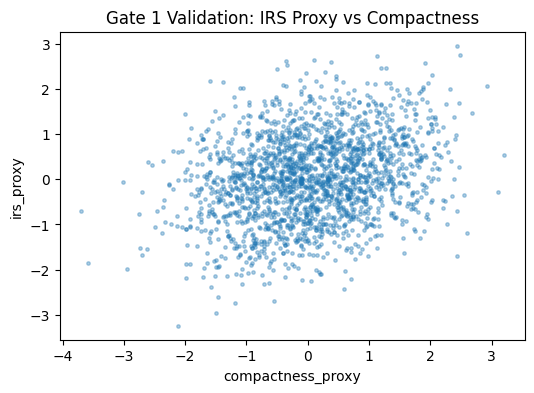

In [ ]:
def split_discovery_validation(df: pd.DataFrame, frac_discovery: float = 0.7) -> tuple[pd.DataFrame, pd.DataFrame]:
    perm = rng.permutation(len(df))
    k = int(len(df) * frac_discovery)
    idx_d = perm[:k]
    idx_v = perm[k:]
    return df.iloc[idx_d].copy(), df.iloc[idx_v].copy()

def spearman_rho(x: pd.Series, y: pd.Series) -> float:
    xr = x.rank(method="average")
    yr = y.rank(method="average")
    return float(xr.corr(yr, method="pearson"))

discovery, validation = split_discovery_validation(df_phot, frac_discovery=0.7)

rho_d = spearman_rho(discovery["irs_proxy"], discovery["compactness_proxy"])
rho_v = spearman_rho(validation["irs_proxy"], validation["compactness_proxy"])

gate1_data_mode = globals().get("gate1_data_mode", "unknown")
is_falsifier_grade_gate1 = gate1_data_mode == "live_tap"
if getattr(cfg, "strict_falsifier_mode", True) and not is_falsifier_grade_gate1:
    gate1_pass = False
else:
    gate1_pass = (len(df_phot) >= cfg.min_n) and (abs(rho_v) >= cfg.min_abs_rho)

gate1 = {
    "n_total": int(len(df_phot)),
    "rho_discovery": rho_d,
    "rho_validation": rho_v,
    "min_abs_rho": cfg.min_abs_rho,
    "min_n": cfg.min_n,
    "data_mode": gate1_data_mode,
    "falsifier_grade": bool(is_falsifier_grade_gate1),
    "gate1_pass": bool(gate1_pass),
}

gate1_path = out_dir / "gate1_metrics.json"
gate1_path.write_text(json.dumps(gate1, indent=2), encoding="utf-8")
print(json.dumps(gate1, indent=2))
print(f"Saved: {gate1_path}")

if plt is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sample = validation.sample(min(2000, len(validation)), random_state=cfg.seed)
    ax.scatter(sample["compactness_proxy"], sample["irs_proxy"], s=6, alpha=0.35)
    ax.set_title("Gate 1 Validation: IRS Proxy vs Compactness")
    ax.set_xlabel("compactness_proxy")
    ax.set_ylabel("irs_proxy")
    plt.show()

In [ ]:
def shuffled_rho_test(df: pd.DataFrame, n_iter: int = 200) -> dict:
    observed = spearman_rho(df["irs_proxy"], df["compactness_proxy"])
    shuffled = []
    y = df["compactness_proxy"].to_numpy(copy=True)

    for _ in range(n_iter):
        rng.shuffle(y)
        rho = spearman_rho(df["irs_proxy"], pd.Series(y))
        shuffled.append(rho)

    shuffled = np.asarray(shuffled, dtype=float)
    return {
        "observed_rho": float(observed),
        "mean_shuffle_rho": float(shuffled.mean()),
        "std_shuffle_rho": float(shuffled.std(ddof=1)),
        "p_empirical": float(np.mean(np.abs(shuffled) >= abs(observed)))
    }

def bootstrap_rho(df: pd.DataFrame, n_boot: int = 500) -> dict:
    n = len(df)
    vals = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        b = df.iloc[idx]
        vals[i] = spearman_rho(b["irs_proxy"], b["compactness_proxy"])

    lo, hi = np.quantile(vals, [0.025, 0.975])
    return {
        "rho_median": float(np.median(vals)),
        "rho_ci95_lo": float(lo),
        "rho_ci95_hi": float(hi)
    }

null_test = shuffled_rho_test(validation, n_iter=200)
boot_test = bootstrap_rho(validation, n_boot=500)

gate1_data_mode = globals().get("gate1_data_mode", "unknown")
is_falsifier_grade_gate2 = gate1_data_mode == "live_tap"
if getattr(cfg, "strict_falsifier_mode", True) and not is_falsifier_grade_gate2:
    gate2_pass = False
else:
    gate2_pass = abs(null_test["mean_shuffle_rho"]) <= cfg.max_null_rho

gate2 = {
    "null_test": null_test,
    "bootstrap": boot_test,
    "max_null_rho": cfg.max_null_rho,
    "data_mode": gate1_data_mode,
    "falsifier_grade": bool(is_falsifier_grade_gate2),
    "gate2_pass": bool(gate2_pass),
}

gate2_path = out_dir / "gate2_robustness.json"
gate2_path.write_text(json.dumps(gate2, indent=2), encoding="utf-8")
print(json.dumps(gate2, indent=2))
print(f"Saved: {gate2_path}")

{
  "null_test": {
    "observed_rho": 0.2348408105587045,
    "mean_shuffle_rho": 0.001725074808945297,
    "std_shuffle_rho": 0.03200205493674303,
    "p_empirical": 0.0
  },
  "bootstrap": {
    "rho_median": 0.23402969071237417,
    "rho_ci95_lo": 0.20359780485719328,
    "rho_ci95_hi": 0.26375556161577485
  },
  "max_null_rho": 0.05,
  "gate2_pass": true
}
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate2_robustness.json


## Gate 3 (IRS Weak-Lensing Extension)

Use this only after Gate 1 and Gate 2 pass.

Planned actions:
- Build lens-source geometry sample with quality masks from DR shear products.
- Stack tangential shear profiles in bins of IRS proxy and host compactness.
- Compare profile-shape predictions from IRS boundary-layer response parameterization.
- Require consistency across redshift and environment bins before progression.

In [33]:
gate3_todo = {
    "status": "not_started",
    "notes": [
        "Confirm DR shear table names and mandatory quality cuts in RSP docs",
        "Implement radial-bin shear stacker with random-point subtraction",
        "Define IRS profile mismatch statistic and pass/fail threshold"
    ],
    "query_preview": build_lensing_query(cfg.lens_table)
}

gate3_path = out_dir / "gate3_plan.json"
gate3_path.write_text(json.dumps(gate3_todo, indent=2), encoding="utf-8")
print(f"Saved: {gate3_path}")
print(gate3_todo["query_preview"][:500] + "...")

Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate3_plan.json
SELECT
    objectId,
    ra, dec,
    e1, e2,
    weight,
    photoz
FROM dr1.shape_measurements
WHERE e1 IS NOT NULL
  AND e2 IS NOT NULL
LIMIT 300000...


## Gate 4 (KSL Complementary Channel)

Use this after IRS gates are stable.

Planned actions:
- Build AGN light-curve sample from Rubin time-domain tables.
- Compute variability descriptors (amplitude, asymmetry, characteristic timescale proxies).
- Cross-link host photometry from Gate 1 to evaluate IRS-KSL overlap hypotheses.
- Export ranked enrichment-anomaly follow-up candidate list for spectroscopy.

In [34]:
gate4_todo = {
    "status": "not_started",
    "notes": [
        "Confirm DR light-curve table and cadence fields",
        "Implement per-object variability feature extractor",
        "Define KSL pass/fail event-rate and host-coupling thresholds"
    ],
    "query_preview": build_agn_query(cfg.agn_table)
}

gate4_path = out_dir / "gate4_plan.json"
gate4_path.write_text(json.dumps(gate4_todo, indent=2), encoding="utf-8")
print(f"Saved: {gate4_path}")
print(gate4_todo["query_preview"][:500] + "...")

Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\gate4_plan.json
SELECT
    objectId,
    mjd,
    band,
    psfFlux,
    psfFluxErr
FROM dr1.source
WHERE psfFlux IS NOT NULL
  AND psfFluxErr > 0
LIMIT 250000...


In [47]:
gate05_data_mode = str(globals().get("overlap_report", {}).get("data_mode", "unknown"))
gate1_data_mode = str(globals().get("gate1_data_mode", "unknown"))

gate05_falsifier = gate05_data_mode == "live_tap"
gate12_falsifier = gate1_data_mode == "live_tap"
falsifier_grade = gate05_falsifier and gate12_falsifier and (not cfg.dry_run)

# Fail closed: if Gate 1/2 are not live-provenance in strict mode, overwrite legacy artifacts
strict_mode = bool(getattr(cfg, "strict_falsifier_mode", True))
if strict_mode and not gate12_falsifier:
    gate1 = {
        "n_total": int(globals().get("df_phot", pd.DataFrame()).shape[0]) if "df_phot" in globals() else 0,
        "rho_discovery": None,
        "rho_validation": None,
        "min_abs_rho": cfg.min_abs_rho,
        "min_n": cfg.min_n,
        "data_mode": gate1_data_mode,
        "falsifier_grade": False,
        "integrity_status": "invalid_non_live_provenance",
        "reason": "Gate 1 metrics are not accepted in strict mode unless produced from live TAP data in the current run.",
        "gate1_pass": False,
    }
    gate1_path = out_dir / "gate1_metrics.json"
    gate1_path.write_text(json.dumps(gate1, indent=2), encoding="utf-8")

    gate2 = {
        "null_test": None,
        "bootstrap": None,
        "max_null_rho": cfg.max_null_rho,
        "data_mode": gate1_data_mode,
        "falsifier_grade": False,
        "integrity_status": "invalid_non_live_provenance",
        "reason": "Gate 2 robustness metrics are not accepted in strict mode unless produced from live TAP data in the current run.",
        "gate2_pass": False,
    }
    gate2_path = out_dir / "gate2_robustness.json"
    gate2_path.write_text(json.dumps(gate2, indent=2), encoding="utf-8")

summary = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "dry_run": cfg.dry_run,
    "strict_falsifier_mode": strict_mode,
    "first_plan": "IRS host-photometry trend falsification",
    "data_provenance": {
        "gate05_data_mode": gate05_data_mode,
        "gate1_gate2_data_mode": gate1_data_mode,
    },
    "falsifier_grade": bool(falsifier_grade),
    "gate_results": {
        "gate05_pass": bool(gate05.get("gate05_pass", False)) if gate05_falsifier else False,
        "gate1_pass": bool(gate1.get("gate1_pass", False)) if gate12_falsifier else False,
        "gate2_pass": bool(gate2.get("gate2_pass", False)) if gate12_falsifier else False,
        "gate3_status": gate3_todo.get("status", "not_started"),
        "gate4_status": gate4_todo.get("status", "not_started")
    },
    "next_action": (
        "Run with live TAP data (cfg.dry_run=False) to obtain falsifier-grade results, then proceed to Gate 3."
        if not falsifier_grade
        else "Proceed to Gate 3 weak-lensing implementation on live data."
    )
}

summary_path = out_dir / "run_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
print(f"Saved: {summary_path}")

{
  "timestamp_utc": "2026-03-24T00:38:38.287208+00:00",
  "dry_run": true,
  "strict_falsifier_mode": true,
  "first_plan": "IRS host-photometry trend falsification",
  "data_provenance": {
    "gate05_data_mode": "none",
    "gate1_gate2_data_mode": "unknown"
  },
  "falsifier_grade": false,
  "gate_results": {
    "gate05_pass": false,
    "gate1_pass": false,
    "gate2_pass": false,
    "gate3_status": "not_started",
    "gate4_status": "not_started"
  },
  "next_action": "Run with live TAP data (cfg.dry_run=False) to obtain falsifier-grade results, then proceed to Gate 3."
}
Saved: d:\#Documents\#Publication\Spacetime_Mechanics__git\rubin_rsp\out\run_summary.json


In [49]:
# Pre-live readiness check: verifies expected artifacts and preregistration lock consistency
import hashlib

required_outputs = [
    out_dir / "preregistered_plan.json",
    out_dir / "access_request_gameplan.json",
    out_dir / "gate05_transfer_metrics.json",
    out_dir / "gate1_photometry_raw.csv",
    out_dir / "gate1_metrics.json",
    out_dir / "gate2_robustness.json",
    out_dir / "gate3_plan.json",
    out_dir / "gate4_plan.json",
    out_dir / "run_summary.json",
]

status_rows = []
for p in required_outputs:
    status_rows.append({
        "artifact": str(p),
        "exists": p.exists(),
        "size_bytes": p.stat().st_size if p.exists() else 0,
    })

readiness_df = pd.DataFrame(status_rows)
missing = readiness_df.loc[~readiness_df["exists"], "artifact"].tolist()

print("Pre-live artifact readiness check")
print(readiness_df)

if missing:
    print("\nStatus: NOT READY")
    print("Missing artifacts:")
    for m in missing:
        print(f"- {m}")
else:
    print("\nStatus: READY (artifact-level)")

# Preregistration lock consistency check
lock_status = {"checked": False, "match": False, "reason": None}
gameplan_path = out_dir / "access_request_gameplan.json"
prereg_path = out_dir / "preregistered_plan.json"
if gameplan_path.exists() and prereg_path.exists():
    try:
        gp = json.loads(gameplan_path.read_text(encoding="utf-8"))
        pr = json.loads(prereg_path.read_text(encoding="utf-8"))

        thresholds = {
            "min_abs_rho": cfg.min_abs_rho,
            "max_null_rho": cfg.max_null_rho,
            "min_n": cfg.min_n,
            "transfer_min_overlap": TRANSFER_MIN_OVERLAP if "TRANSFER_MIN_OVERLAP" in globals() else 20,
            "transfer_min_abs_rho": TRANSFER_MIN_ABS_RHO if "TRANSFER_MIN_ABS_RHO" in globals() else 0.40,
        }
        payload = {
            "study_name": pr.get("study_name"),
            "hypotheses": pr.get("hypotheses", []),
            "stop_conditions": pr.get("stop_conditions", []),
            "thresholds": thresholds,
        }
        expected_hash = hashlib.sha256(
            json.dumps(payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
        ).hexdigest()

        recorded_hash = (
            gp.get("integrity_controls", {})
              .get("preregistration_lock", {})
              .get("hash")
        )

        lock_status = {
            "checked": True,
            "match": expected_hash == recorded_hash,
            "expected_hash": expected_hash,
            "recorded_hash": recorded_hash,
        }
    except Exception as exc:
        lock_status = {"checked": True, "match": False, "reason": f"lock check failed: {exc}"}

print("\nPreregistration lock check")
print(json.dumps(lock_status, indent=2))
if lock_status.get("checked") and not lock_status.get("match", False):
    print("Integrity warning: regenerate preregistration + gameplan cell before external submission.")

# Canonical overlap input check for Gate 0.5 live pass path
overlap_candidate = (DATA_DIR / "sparc_rubin_overlap.csv") if "DATA_DIR" in globals() else Path("rubin_rsp/data/sparc_rubin_overlap.csv")
print(f"\nGate 0.5 overlap input present: {overlap_candidate.exists()} ({overlap_candidate})")

Pre-live artifact readiness check
                                            artifact  exists  size_bytes
0  d:\#Documents\#Publication\Spacetime_Mechanics...    True         737
1  d:\#Documents\#Publication\Spacetime_Mechanics...    True        2982
2  d:\#Documents\#Publication\Spacetime_Mechanics...    True         297
3  d:\#Documents\#Publication\Spacetime_Mechanics...    True     2118676
4  d:\#Documents\#Publication\Spacetime_Mechanics...    True         371
5  d:\#Documents\#Publication\Spacetime_Mechanics...    True         335
6  d:\#Documents\#Publication\Spacetime_Mechanics...    True         453
7  d:\#Documents\#Publication\Spacetime_Mechanics...    True         410
8  d:\#Documents\#Publication\Spacetime_Mechanics...    True         605

Status: READY (artifact-level)

Preregistration lock check
{
  "checked": true,
  "match": true,
  "expected_hash": "c9a7b7c4df91bdae2a708ccf5bd16d5e288f23bd4e328259e8aa34e5ff7c322b",
  "recorded_hash": "c9a7b7c4df91bdae2a708ccf5bd16d5

## Execution Checklist Once Rubin Access Is Approved

1. Confirm the gameplan artifact in `rubin_rsp/out/access_request_gameplan.json` and keep the lock hash unchanged unless hypotheses are intentionally revised.
2. Set `cfg.dry_run = False`.
3. Confirm TAP endpoint and DR table/column names from RSP schema browser.
4. Run notebook top-to-bottom and inspect `rubin_rsp/out/` artifacts.
5. Confirm provenance fields are `live_tap` and `run_summary.json` reports `falsifier_grade: true` before any empirical claim.
6. Only proceed to Gate 3 and Gate 4 if Gate 0.5, Gate 1, and Gate 2 pass on live data.

This notebook is intended to be strict, auditable, and ready for a Rubin access request centered on robust falsification.